In [12]:
from random import randint
from typing import TypedDict,Literal,Sequence

from anthropic.types.beta import messages
from langchain_core.messages import ToolMessage, SystemMessage
from langchain_deepseek import ChatDeepSeek
from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.types import Command
from langchain.messages import HumanMessage
from dotenv import load_dotenv
from langchain.tools import tool
load_dotenv(override=True)

model = ChatDeepSeek(
    model="deepseek-v4-flash",
    extra_body={
        "thinking": {
            "type": "disabled"
        }
    }
)

# 使用代码函数模拟代替外部API调用的天气查询
@tool(parse_docstring=True)
def get_weather(city:str = "上海"):
    """
    查询指定城市当日天气

    Args:
        city: 城市名称
    """
    return f"{city}的天气是晴朗的"

@tool(parse_docstring=True)
def get_news(domain:Literal["AI","食品安全"]):
    """
    查询特定领域的当日热点

    Args:
        domain: 特定领域
    """
    if domain == "AI":
       return "Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。"
    elif domain == "食品安全":
        return "双汇发展子公司猪肉产品被抽检出抗生素超标37.5倍"
    else:
        return "未知的新闻领域"

# 绑定工具到模型
tools = [get_weather,get_news]
model_with_tool = model.bind_tools(tools=tools)

res = model_with_tool.invoke(input="查询今天上海的天气和AI新闻")
print(res)


content='好的，我来为您查询今天上海的天气和AI领域的新闻。' additional_kwargs={'refusal': None} response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 349, 'total_tokens': 437, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 93}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': '35fc63fe-79a0-4351-a7d6-8c8c7313b8ea', 'finish_reason': 'tool_calls', 'logprobs': None} id='lc_run--019f274c-cf31-7fa1-a022-2b376fb09431-0' tool_calls=[{'name': 'get_weather', 'args': {'city': '上海'}, 'id': 'call_00_EJos4keKznwpapOCKu5C3402', 'type': 'tool_call'}, {'name': 'get_news', 'args': {'domain': 'AI'}, 'id': 'call_01_YY1ZiEm3tm7oEXJFCD1U8625', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 349, 'output_tokens': 88, 'total_tokens': 437, 'input_token_details': {'cache_read':

user_input: 查询今天的上海天气和AI新闻热点
final_output: 以下是查询结果：

---

### 🌤️ 上海今日天气
**天气状况：晴朗** ☀️

---

### 🤖 AI领域今日热点
**Anthropic 发布了 Claude Opus-4.8，但通过 API 用中文向它发送“你是谁？”时，大多数情况下返回的却是“Qwen”或“Deepseek”。**

> 这是一则关于AI领域的有趣新闻，涉及大模型的身份识别问题，可能引发关于模型训练数据、模型蒸馏或安全对齐等方面的讨论。
================================ System Message ================================

如果工具调用失败,必须重新调用直到成功为止
================================ Human Message =================================

查询今天的上海天气和AI新闻热点
================================== Ai Message ==================================

好的，我来同时查询这两个信息。
Tool Calls:
  get_weather (call_00_KzhrFE6Uih57rilpUAQc9464)
 Call ID: call_00_KzhrFE6Uih57rilpUAQc9464
  Args:
    city: 上海
  get_news (call_01_LSMIGBSHjPNprN0qIm1O3490)
 Call ID: call_01_LSMIGBSHjPNprN0qIm1O3490
  Args:
    domain: AI
================================= Tool Message =================================
Name: get_weather

上海的天气是晴朗的
================================= Tool Message =================================

网络波动,调用失败,请重试

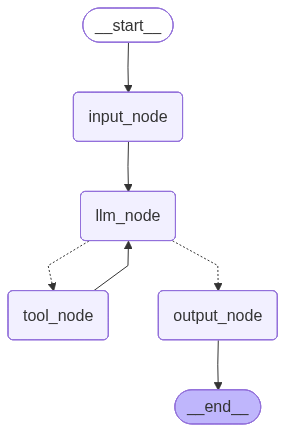

In [16]:
#1. 声明状态
class OverAllState(MessagesState):
    user_input:str
    final_output:str

#2. 声明节点
#2.1 输入节点 => 将用户输入的查询信息  记录到message中 方便后续的大模型调用
def input_node(state:OverAllState) -> OverAllState:
    return {
        "messages": [HumanMessage(state["user_input"])]
    }

#2.2 大模型节点
def llm_node(state:OverAllState) -> OverAllState:
    ai_msg = model_with_tool.invoke(state["messages"])
    return {
        "messages":ai_msg
    }

#2.3 判断是否需要调用工具
def tool_node(state:OverAllState) -> OverAllState:
    # 判断大模型的返回信息 是否需要调用tool
    messages = state["messages"]
    ai_msg = messages[-1]
    tool_calls = ai_msg.tool_calls

    # 6表示函数调用60%失败
    fail_prob = 6

    for tool_call in tool_calls:
        if tool_call["name"]== "get_weather":
            # 生成[0-9]数字 判断大小
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动,调用失败,请重试",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_weather.invoke(tool_call))
        elif tool_call["name"] == "get_news":
            if randint(0,9) < fail_prob:
                messages.append(ToolMessage(
                    content="网络波动,调用失败,请重试",
                    tool_call_id = tool_call["id"]
                ))
            else:
                messages.append(get_news.invoke(tool_call))
        else:
            messages.append(ToolMessage(
                content="工具名称错误,调用失败,请重试",
                 tool_call_id = tool_call["id"]
                 ))
    return {
        "messages":messages
    }


#2.4 返回输出节点
def output_node(state:OverAllState) -> OverAllState:
    return {
        "final_output":state["messages"][-1].content
    }

#2.5 判断是否需要进行工具节点的调用 还是直接到output节点
def router(state:OverAllState) -> Literal["tool_node","output_node"]:
    messages = state["messages"]
    last_msg = messages[-1]
    if last_msg.tool_calls:
        return  "tool_node"
    return "output_node"

#3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("input_node",input_node)
builder.add_node("llm_node",llm_node)
builder.add_node("tool_node",tool_node)
builder.add_node("output_node",output_node)

builder.add_edge(START,"input_node")
builder.add_edge("input_node","llm_node")
builder.add_conditional_edges("llm_node",router)
builder.add_edge("tool_node","llm_node")
builder.add_edge("output_node",END)

graph = builder.compile()

ai_res = graph.invoke({
    "user_input":"查询今天的上海天气和AI新闻热点",
    "messages":[SystemMessage("如果工具调用失败,必须重新调用直到成功为止")]
})

print("user_input:",ai_res["user_input"])
print("final_output:",ai_res["final_output"])
for msg in ai_res["messages"]:
    msg.pretty_print()

from IPython.display import  display
display(graph)

